<a href="https://colab.research.google.com/github/financieras/articulos/blob/main/Fundamentos_de_la_Regresi%C3%B3n_Lineal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fundamentos de la Regresión Lineal
## Gradient Descent vs Scikit-learn en un caso práctico

___

# 1. Introducción

## 1.1 ¿Qué es la Regresión Lineal?

La regresión lineal es uno de los algoritmos fundamentales en Machine Learning. Su objetivo es encontrar la **mejor línea recta** que describe la relación entre dos variables.

Matemáticamente, buscamos una función:

$$y = \theta_0 + \theta_1 \cdot x$$

Donde:
- **y**: variable que queremos predecir (precio)
- **x**: variable conocida (metros cuadrados)
- **θ₀**: intercepto (precio cuando x=0)
- **θ₁**: pendiente (cuánto aumenta el precio por cada m²)

## 1.2 Aplicación práctica: Predecir precios de viviendas

Imagina que eres un agente inmobiliario y necesitas estimar rápidamente el precio de una vivienda conociendo únicamente sus metros cuadrados. La regresión lineal te permite:

✓ Hacer predicciones basadas en datos históricos  
✓ Entender la relación entre tamaño y precio  
✓ Detectar viviendas sobre o infravaloradas

---

# 2. El Dataset

## 2.1 Descripción de los datos de precios de casas

Trabajaremos con un conjunto de 10 viviendas de segunda mano, donde conocemos:
- **Área**: metros cuadrados de la vivienda
- **Precio**: precio de venta en miles de dólares

## 2.2 Carga, exploración básica y visualización

Number of houses: 10
Area range: 50m² - 100m²
Price range: $140k - $300k
Average price per m²: $2.94k


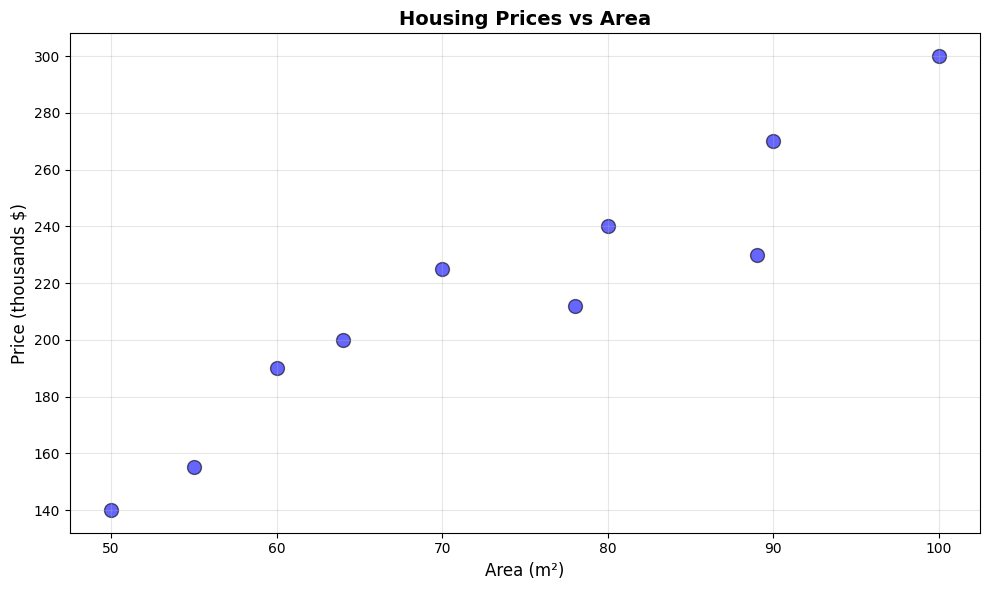

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Data: housing area (m²) vs price (thousands $)
area = np.array([50, 55, 60, 64, 70, 78, 80, 89, 90, 100])
price = np.array([140, 155, 190, 200, 225,
                  212, 240, 230, 270, 300])

# Basic exploration
print(f"Number of houses: {len(area)}")
print(f"Area range: {area.min()}m² - {area.max()}m²")
print(f"Price range: ${price.min()}k - ${price.max()}k")
print(f"Average price per m²: ${(price/area).mean():.2f}k")

# Visualization
plt.figure(figsize=(10, 6))
plt.scatter(area, price, color='blue', s=100, alpha=0.6, edgecolors='black')
plt.xlabel('Area (m²)', fontsize=12)
plt.ylabel('Price (thousands $)', fontsize=12)
plt.title('Housing Prices vs Area', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Observación**: Se aprecia una tendencia positiva: a mayor área, mayor precio.

## 2.3 ¿Por qué normalizar? La importancia del escalado

Al usar Gradient Descent, las variables con escalas diferentes pueden causar problemas:

- **Sin normalizar**: Área (50-100) vs Precio (140-300)
- El algoritmo converge **lentamente** o de forma **inestable**
- Los pasos del gradiente son desproporcionados

**Solución: Z-score normalization**

$$z = \frac{x - \mu}{\sigma}$$

Transforma los datos para que tengan media=0 y desviación estándar=1.

In [2]:
def normalize(data):
    """
    Normalize data using Z-score normalization.

    Args:
        data: numpy array to normalize

    Returns:
        normalized_data: normalized array
        mean: original mean
        std: original standard deviation
    """
    mean = data.mean()
    std = data.std()
    normalized_data = (data - mean) / std
    return normalized_data, mean, std

# Normalize our data
area_norm, area_mean, area_std = normalize(area)
price_norm, price_mean, price_std = normalize(price)

print("Original area:", area[:3])
print("Normalized area:", area_norm[:3])
print(f"\nNormalized area - Mean: {area_norm.mean():.2e}, Std: {area_norm.std():.2f}")

Original area: [50 55 60]
Normalized area: [-1.50578324 -1.18676137 -0.86773949]

Normalized area - Mean: 3.11e-16, Std: 1.00


**Importante**: Guardaremos `mean` y `std` para desnormalizar las predicciones finales.

---

# 3. Conceptos clave

## 3.1 La recta de regresión

Nuestro objetivo es encontrar los parámetros **θ₀** (intercepto) y **θ₁** (pendiente) que mejor ajusten nuestros datos.

La predicción para cualquier valor de x se calcula como:

$$\hat{y} = \theta_0 + \theta_1 \cdot x$$

Donde $\hat{y}$ es el precio predicho para una vivienda de x metros cuadrados.

## 3.2 La función de Coste: midiendo el error

Para saber qué tan buena es nuestra recta, necesitamos medir el **error** entre los valores reales y las predicciones.

**Mean Squared Error (MSE)**:

$$MSE = \frac{1}{m} \sum_{i=1}^{m} (y_i - \hat{y}_i)^2$$

**Función de Coste** (la que minimizaremos):

$$J(\theta_0, \theta_1) = \frac{1}{2m} \sum_{i=1}^{m} (y_i - \hat{y}_i)^2$$

Donde:
- **m**: número de ejemplos (10 viviendas)
- **$y_i$**: precio real de la vivienda i
- **$\hat{y}_i$**: precio predicho de la vivienda i

El factor $\frac{1}{2}$ simplifica las derivadas (veremos por qué a continuación).

**Root Mean Squared Error (RMSE)**: $\sqrt{MSE}$ - útil porque está en las mismas unidades que y (miles de $).

## 3.3 Calculando el Gradiente

El gradiente nos indica la **dirección** en la que debemos ajustar θ₀ y θ₁ para reducir el error.

Las derivadas parciales de J respecto a cada parámetro son:

$$\frac{\partial J}{\partial \theta_0} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i)$$

$$\frac{\partial J}{\partial \theta_1} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i) \cdot x_i$$

Estas fórmulas nos dicen **cuánto y en qué dirección** cambiar cada parámetro.

## 3.4 El Algoritmo: ajustando los pesos del modelo

**Gradient Descent** actualiza los parámetros iterativamente:

$$\theta_0 := \theta_0 - \alpha \cdot \frac{\partial J}{\partial \theta_0}$$

$$\theta_1 := \theta_1 - \alpha \cdot \frac{\partial J}{\partial \theta_1}$$

Donde:
- **α (alpha)**: learning rate o tasa de aprendizaje
  - Muy pequeño → convergencia lenta
  - Muy grande → puede no converger
  - Típicamente: 0.001 - 0.1

**Proceso**:
1. Inicializar θ₀ = 0, θ₁ = 0
2. Calcular predicciones con los θ actuales
3. Calcular el gradiente (derivadas parciales)
4. Actualizar θ₀ y θ₁
5. Repetir pasos 2-4 hasta convergencia

In [3]:
# Pseudocode visualization
def gradient_descent_concept():
    """
    Conceptual representation of gradient descent.
    """
    theta_0 = 0
    theta_1 = 0
    alpha = 0.01

    for iteration in range(1000):
        # Predictions
        predictions = theta_0 + theta_1 * X

        # Calculate gradients
        gradient_theta_0 = (1/m) * sum(predictions - y)
        gradient_theta_1 = (1/m) * sum((predictions - y) * X)

        # Update parameters
        theta_0 = theta_0 - alpha * gradient_theta_0
        theta_1 = theta_1 - alpha * gradient_theta_1

    return theta_0, theta_1

En la siguiente sección implementaremos este algoritmo completo.

---

# 4. Implementación manual

## 4.1 Código del Descenso del Gradiente

In [4]:
def gradient_descent(X, y, learning_rate=0.01, iterations=1000):
    """
    Implement gradient descent algorithm for linear regression.

    Args:
        X: input features (normalized)
        y: target values (normalized)
        learning_rate: step size for parameter updates
        iterations: number of training iterations

    Returns:
        theta_0: intercept
        theta_1: slope
        cost_history: list of cost values per iteration
    """
    m = len(X)  # number of training examples
    theta_0 = 0.0
    theta_1 = 0.0
    cost_history = []

    for i in range(iterations):
        # Predictions
        predictions = theta_0 + theta_1 * X

        # Calculate errors
        errors = predictions - y

        # Calculate gradients
        gradient_theta_0 = (1/m) * np.sum(errors)
        gradient_theta_1 = (1/m) * np.sum(errors * X)

        # Update parameters
        theta_0 = theta_0 - learning_rate * gradient_theta_0
        theta_1 = theta_1 - learning_rate * gradient_theta_1

        # Calculate cost (MSE/2)
        cost = (1/(2*m)) * np.sum(errors**2)
        cost_history.append(cost)

        # Print progress every 100 iterations
        if (i+1) % 100 == 0:
            print(f"Iteration {i+1}: Cost = {cost:.6f}")

    return theta_0, theta_1, cost_history

# Train the model
theta_0, theta_1, cost_history = gradient_descent(
    area_norm,
    price_norm,
    learning_rate=0.1,
    iterations=1000
)

print(f"\nFinal parameters (normalized):")
print(f"θ₀ (intercept) = {theta_0:.6f}")
print(f"θ₁ (slope) = {theta_1:.6f}")

Iteration 100: Cost = 0.049929
Iteration 200: Cost = 0.049929
Iteration 300: Cost = 0.049929
Iteration 400: Cost = 0.049929
Iteration 500: Cost = 0.049929
Iteration 600: Cost = 0.049929
Iteration 700: Cost = 0.049929
Iteration 800: Cost = 0.049929
Iteration 900: Cost = 0.049929
Iteration 1000: Cost = 0.049929

Final parameters (normalized):
θ₀ (intercept) = -0.000000
θ₁ (slope) = 0.948758


## 4.2 Entrenamiento y visualización de resultados


Final parameters (original scale):
θ₀ (intercept) = 10.72 (thousands $)
θ₁ (slope) = 2.79 (thousands $ per m²)


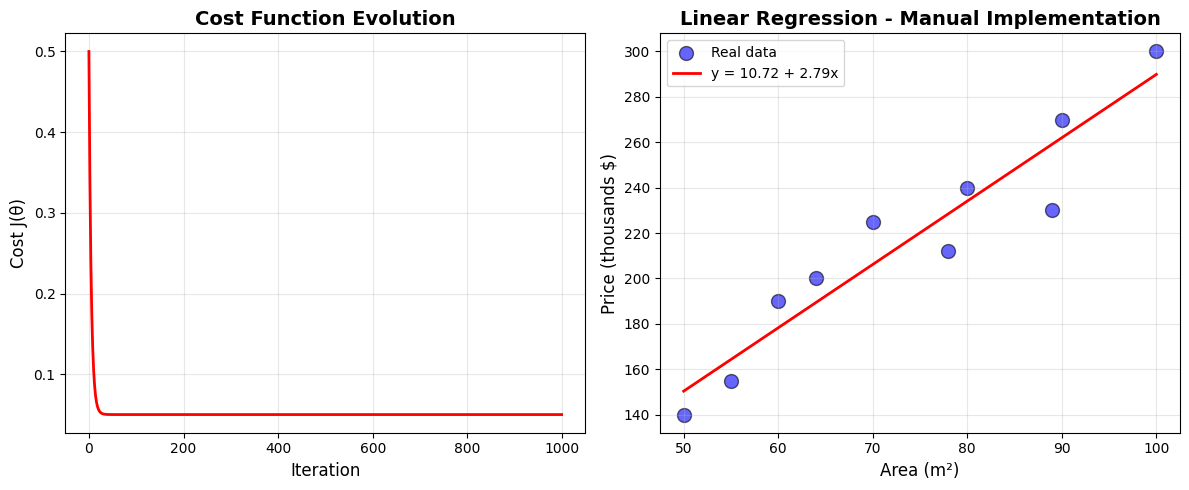


Example prediction:
House of 75m² → $220.11k


In [5]:
# Denormalize parameters to original scale
# For linear transformation: y = theta_0 + theta_1 * x
# When denormalizing: y_original = y_norm * price_std + price_mean
# x_original = x_norm * area_std + area_mean
theta_1_original = theta_1 * (price_std / area_std)
theta_0_original = price_mean - theta_1_original * area_mean

print(f"\nFinal parameters (original scale):")
print(f"θ₀ (intercept) = {theta_0_original:.2f} (thousands $)")
print(f"θ₁ (slope) = {theta_1_original:.2f} (thousands $ per m²)")

# Make predictions
predictions_norm = theta_0 + theta_1 * area_norm
predictions = predictions_norm * price_std + price_mean

# Visualize cost evolution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(cost_history, color='red', linewidth=2)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Cost J(θ)', fontsize=12)
plt.title('Cost Function Evolution', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(area, price, color='blue', s=100, alpha=0.6,
            edgecolors='black', label='Real data')
plt.plot(area, predictions, color='red', linewidth=2,
         label=f'y = {theta_0_original:.2f} + {theta_1_original:.2f}x')
plt.xlabel('Area (m²)', fontsize=12)
plt.ylabel('Price (thousands $)', fontsize=12)
plt.title('Linear Regression - Manual Implementation', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Example prediction
example_area = 75
example_area_norm = (example_area - area_mean) / area_std
example_prediction_norm = theta_0 + theta_1 * example_area_norm
example_prediction = example_prediction_norm * price_std + price_mean

print(f"\nExample prediction:")
print(f"House of {example_area}m² → ${example_prediction:.2f}k")

**Interpretación**:
- **θ₁**: Por cada m² adicional, el precio aumenta aproximadamente θ₁ miles de dólares
- **θ₀**: Precio base (intercepto con el eje Y)
- La **curva de coste** debe decrecer y estabilizarse, indicando convergencia

---

# 5. Usando Scikit-learn

## 5.1 Implementación

Scikit-learn proporciona una implementación optimizada de regresión lineal que resuelve el problema de forma analítica (ecuaciones normales) en lugar de usar Gradient Descent.

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Create and train the model
model = LinearRegression()

# Reshape data for sklearn (requires 2D array)
X_train = area.reshape(-1, 1)
y_train = price

# Fit the model
model.fit(X_train, y_train)

# Get parameters
theta_0_sklearn = model.intercept_
theta_1_sklearn = model.coef_[0]

print("Scikit-learn parameters:")
print(f"θ₀ (intercept) = {theta_0_sklearn:.2f} (thousands $)")
print(f"θ₁ (slope) = {theta_1_sklearn:.2f} (thousands $ per m²)")

Scikit-learn parameters:
θ₀ (intercept) = 10.72 (thousands $)
θ₁ (slope) = 2.79 (thousands $ per m²)


## 5.2 Entrenamiento y predicciones


Metrics:
MSE = 212.39
RMSE = 14.57 (thousands $)
R² = 0.9001


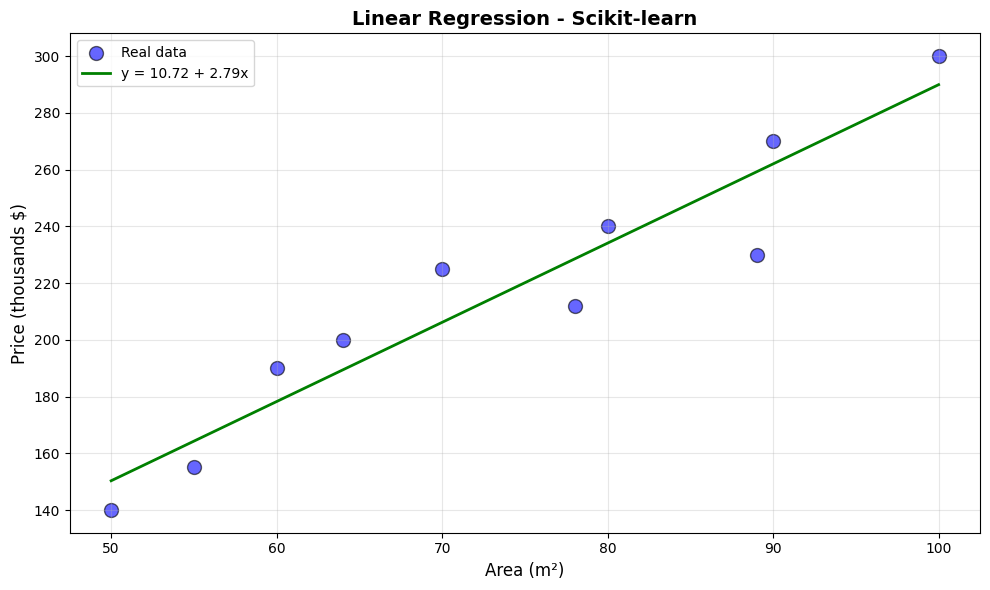


Example prediction:
House of 75m² → $220.11k


In [7]:
# Make predictions
predictions_sklearn = model.predict(X_train)

# Calculate metrics
mse_sklearn = mean_squared_error(y_train, predictions_sklearn)
rmse_sklearn = np.sqrt(mse_sklearn)
r2_sklearn = r2_score(y_train, predictions_sklearn)

print(f"\nMetrics:")
print(f"MSE = {mse_sklearn:.2f}")
print(f"RMSE = {rmse_sklearn:.2f} (thousands $)")
print(f"R² = {r2_sklearn:.4f}")

# Visualize results
plt.figure(figsize=(10, 6))
plt.scatter(area, price, color='blue', s=100, alpha=0.6,
            edgecolors='black', label='Real data')
plt.plot(area, predictions_sklearn, color='green', linewidth=2,
         label=f'y = {theta_0_sklearn:.2f} + {theta_1_sklearn:.2f}x')
plt.xlabel('Area (m²)', fontsize=12)
plt.ylabel('Price (thousands $)', fontsize=12)
plt.title('Linear Regression - Scikit-learn', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Example prediction
example_prediction_sklearn = model.predict([[75]])[0]
print(f"\nExample prediction:")
print(f"House of 75m² → ${example_prediction_sklearn:.2f}k")

**Ventajas de Scikit-learn**:
- **Más rápido**: solución analítica directa
- **No requiere normalización**: maneja diferentes escalas automáticamente
- **No requiere ajustar hiperparámetros**: sin learning rate ni iteraciones
- **Menos código**: implementación en pocas líneas

---

# 6. Comparación y evaluación

## 6.1 Resultados lado a lado

                   Method  θ₀ (intercept)  θ₁ (slope)
Manual (Gradient Descent)       10.722846    2.791809
             Scikit-learn       10.722846    2.791809

Metrics comparison:
Method                         MSE        RMSE       R²        
------------------------------------------------------------
Manual (Gradient Descent)      212.39     14.57      0.9001    
Scikit-learn                   212.39     14.57      0.9001    


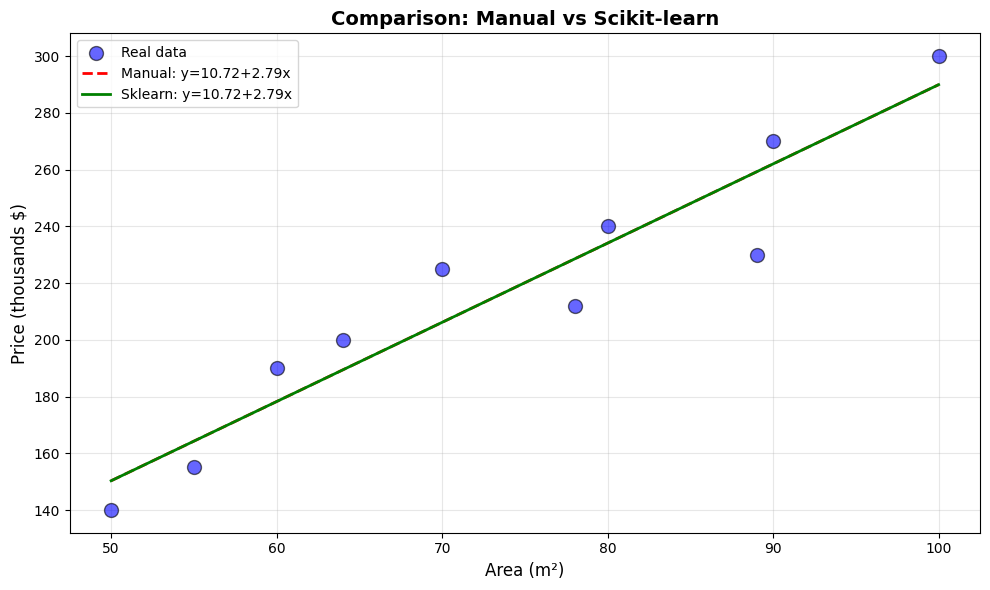

In [8]:
# Compare parameters
comparison_df = {
    'Method': ['Manual (Gradient Descent)', 'Scikit-learn'],
    'θ₀ (intercept)': [theta_0_original, theta_0_sklearn],
    'θ₁ (slope)': [theta_1_original, theta_1_sklearn]
}

import pandas as pd
df = pd.DataFrame(comparison_df)
print(df.to_string(index=False))

# Calculate metrics for manual implementation
mse_manual = mean_squared_error(price, predictions)
rmse_manual = np.sqrt(mse_manual)
r2_manual = r2_score(price, predictions)

print(f"\nMetrics comparison:")
print(f"{'Method':<30} {'MSE':<10} {'RMSE':<10} {'R²':<10}")
print(f"{'-'*60}")
print(f"{'Manual (Gradient Descent)':<30} {mse_manual:<10.2f} {rmse_manual:<10.2f} {r2_manual:<10.4f}")
print(f"{'Scikit-learn':<30} {mse_sklearn:<10.2f} {rmse_sklearn:<10.2f} {r2_sklearn:<10.4f}")

# Visual comparison
plt.figure(figsize=(10, 6))
plt.scatter(area, price, color='blue', s=100, alpha=0.6,
            edgecolors='black', label='Real data', zorder=3)
plt.plot(area, predictions, color='red', linewidth=2,
         label=f'Manual: y={theta_0_original:.2f}+{theta_1_original:.2f}x', linestyle='--')
plt.plot(area, predictions_sklearn, color='green', linewidth=2,
         label=f'Sklearn: y={theta_0_sklearn:.2f}+{theta_1_sklearn:.2f}x')
plt.xlabel('Area (m²)', fontsize=12)
plt.ylabel('Price (thousands $)', fontsize=12)
plt.title('Comparison: Manual vs Scikit-learn', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6.2 Métricas: R² e interpretaciones

**Coeficiente de Determinación (R²)**:

$$R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$$

**Interpretación**:
- **R² ≈ 1**: Excelente ajuste, el modelo explica casi toda la variabilidad
- **R² ≈ 0.7-0.9**: Buen ajuste para ciencias sociales/economía
- **R² < 0.5**: Ajuste pobre, considerar otras variables o modelos no lineales

In [9]:
print(f"\nInterpretation:")
print(f"Our model explains {r2_sklearn*100:.2f}% of price variance")
print(f"RMSE of ${rmse_sklearn:.2f}k means typical prediction error")


Interpretation:
Our model explains 90.01% of price variance
RMSE of $14.57k means typical prediction error


**Observación**: Ambos métodos convergen a resultados prácticamente idénticos. Las pequeñas diferencias se deben a:
- Gradient Descent: aproximación iterativa
- Scikit-learn: solución analítica exacta

---

# 7. Conclusión

## 7.1 Correlación no es causalidad

Aunque encontramos una relación fuerte entre área y precio, debemos ser cautelosos:

- **Correlación**: Existe una relación estadística (R² alto)
- **Causalidad**: No podemos afirmar que el área *causa* el precio

**Factores omitidos** que también influyen:
- Ubicación de la vivienda
- Estado de conservación
- Año de construcción
- Servicios cercanos

**Ejemplo de correlación espuria**: El consumo de helado correlaciona con ahogamientos en piscinas, pero el helado no *causa* ahogamientos. Ambos aumentan en verano.

> Más ejemplos: [tylervigen.com/spurious-correlations](https://www.tylervigen.com/spurious-correlations)

## 7.2 Cuándo usar regresión lineal

**✓ Usar regresión lineal cuando:**
- La relación entre variables es aproximadamente lineal
- Necesitas un modelo interpretable y simple
- Tienes pocas variables predictoras
- Quieres entender la magnitud del efecto de cada variable

**✗ Evitar regresión lineal cuando:**
- La relación es claramente no lineal (curvas, exponenciales)
- Tienes muchas variables correlacionadas entre sí
- Los datos tienen patrones complejos